<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-2-MateuszOlech/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [26]:
# wczytanie zbioru danych
titanic = pd.read_csv("/content/train.csv")
titanic

#titanic.shape

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [27]:
# MIEJSCE NA TWÓJ KOD
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId - Id pasażera, unikatowe wartości, prawdopodobnie bez znaczenia dla korelacji

Survived - czy przeżył; 1 - Tak, 0 - Nie

Pclass - rodzaj klasy jaką podróżował; zakres (1-3)

Name - Dane osobowe, raczej bez przyszłego zastosowania

Sex - płeć, wartość tekstowa

Age - wiek pasażera (trochę brakuje)

SibSp - ile rodzeństwa/współmałżonków było na pokładzie

Parch - ile rodziców/dzieci było na pokładzie

Ticket - numer biletu, raczej bez późniejszej przydatności

Fare - ile zapłacono za bilet

Cabin - numer kabiny, dużo pustych, prawdopodobnie nie da się zastosować w sprawdzaniu korelacji

Embarked - port zaokrętowania

## Przekształcenie danych

In [ ]:
# MIEJSCE NA TWÓJ KOD
#Zaimplementowane pod uzupełnieniem brakujących danych

## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

<Axes: xlabel='Age', ylabel='Count'>

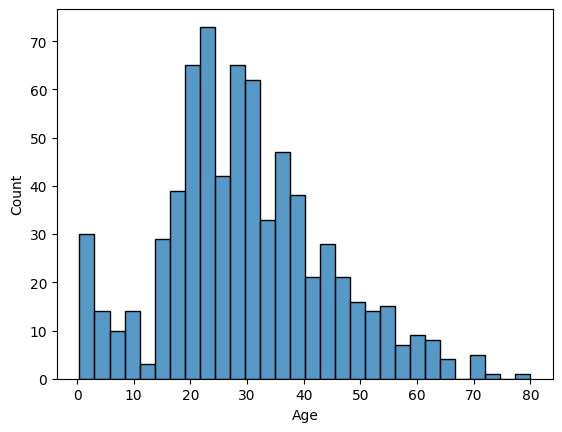

In [28]:
# MIEJSCE NA TWÓJ KOD
titanic = pd.read_csv("/content/train.csv")
sns.histplot(titanic['Age'], bins=30)

Wiek pasażerów jest zróżnicowany, wartością najlepiej oddającą wiek losowego pasażera powinna być mediana

In [29]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [30]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [31]:
# MIEJSCE NA TWÓJ KOD
titanic['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [32]:
print(titanic['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


W przypadku zaokrętowania, mamy trzy możliwe wartości, z czego jedna zdecydowania przeważa nad pozostałymi. Dlatego najlepszym uzupełnieniem brakujących wierszy będzie uzupełnienie ich najczęstszą wartością

In [33]:
titanic['Embarked'] = titanic['Embarked'].fillna('S')

In [34]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

Ponad 70% wierszy jest pustych, oraz nie ma schematu, który pozwalałby na w miarę bezpieczne uzupełnienie brakujących wartości w tej kolumnie. Dlatego jedynym logicznym rozwiązaniem jest usunięcię tej kolumny.

In [35]:
# MIEJSCE NA TWÓJ KOD
titanic = titanic.drop(columns=['Cabin'])

In [36]:
#assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [37]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

In [38]:
# PRZEKSZTAŁCANIE DANYCH
ages = [0, 12, 21, 41, 61, 100]
categories = ['0-11', '12-20', '21-40', '41-60', '61+']
titanic['Age_category'] = pd.cut(titanic['Age'], bins=ages, labels=categories)

titanic['Has_parch'] = titanic['Parch'] > 0

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

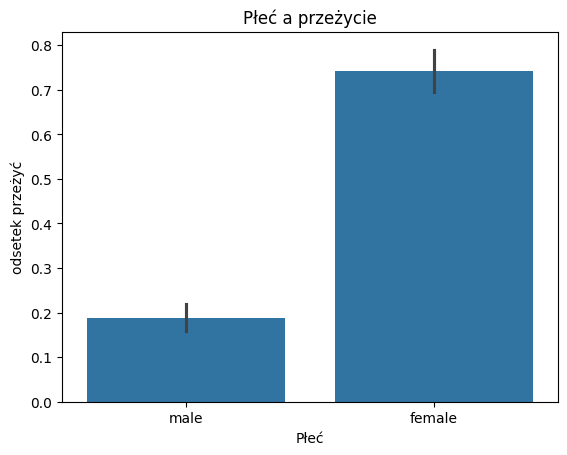

In [39]:
# MIEJSCE NA TWÓJ KOD
sns.barplot(data=titanic, x='Sex', y='Survived')
plt.title('Płeć a przeżycie')
plt.xlabel('Płeć')
plt.ylabel('odsetek przeżyć')
plt.show()

Text(0, 0.5, '')

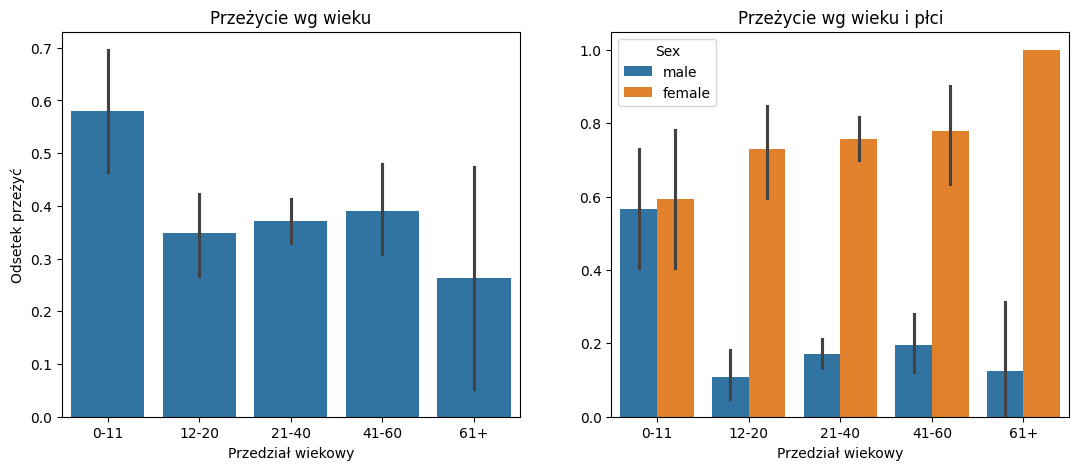

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='Age_category', y='Survived', ax=axes[0])
axes[0].set_title('Przeżycie wg wieku')
axes[0].set_xlabel('Przedział wiekowy')
axes[0].set_ylabel('Odsetek przeżyć')

sns.barplot(data=titanic, x='Age_category', y='Survived', hue='Sex', ax=axes[1])
axes[1].set_title('Przeżycie wg wieku i płci')
axes[1].set_xlabel('Przedział wiekowy')
axes[1].set_ylabel('')

Text(0, 0.5, 'Podział wiekowy')

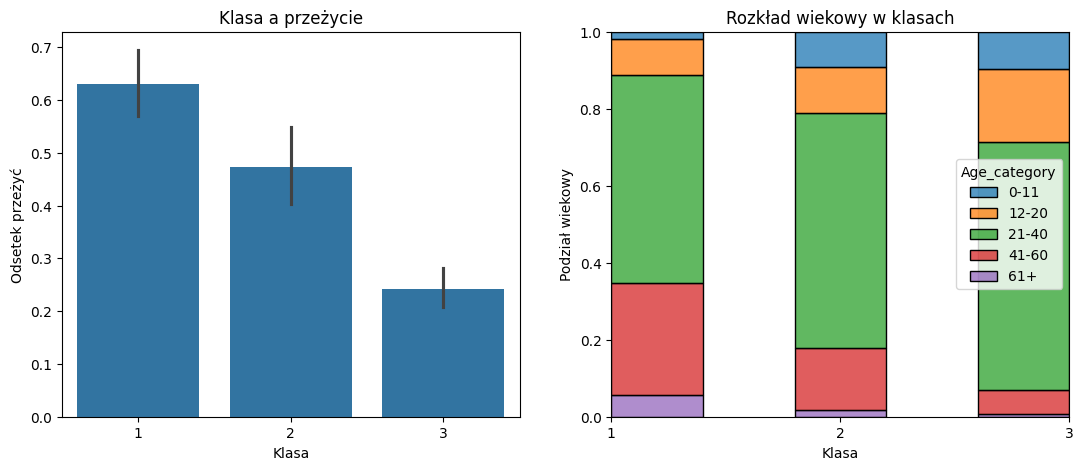

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='Pclass', y='Survived', ax=axes[0])
axes[0].set_title('Klasa a przeżycie')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Odsetek przeżyć')

sns.histplot(data=titanic, x='Pclass', hue='Age_category', multiple='fill', bins=5, ax=axes[1])
axes[1].set_xticks([1, 2, 3])
axes[1].set_title('Rozkład wiekowy w klasach')
axes[1].set_xlabel('Klasa')
axes[1].set_ylabel('Podział wiekowy')

Text(0.5, 1.0, 'Wpływ rodzica/dziecka na przeżycie wg płci')

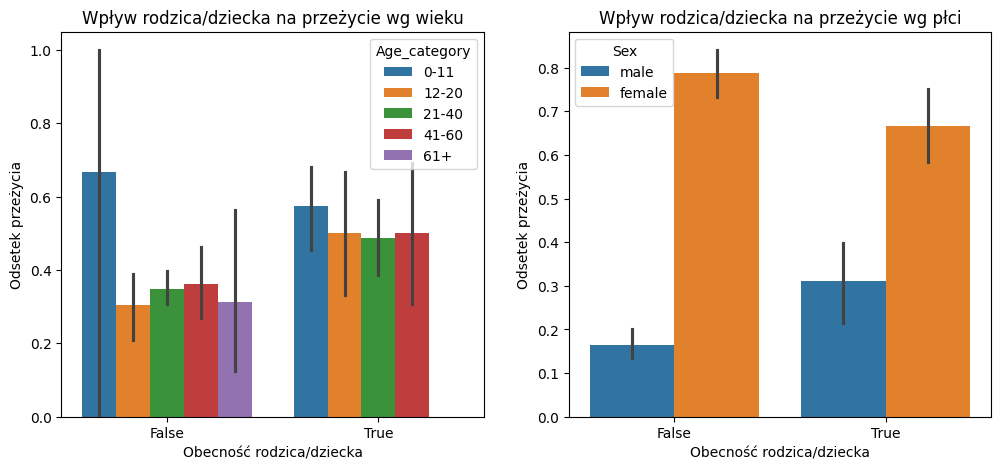

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(
    data=titanic,
    x='Has_parch',
    y='Survived',
    hue='Age_category',
    ax=axes[0]
)
axes[0].set_ylabel('Odsetek przeżycia')
axes[0].set_xlabel('Obecność rodzica/dziecka')
axes[0].set_title('Wpływ rodzica/dziecka na przeżycie wg wieku')

sns.barplot(
    data=titanic,
    x='Has_parch',
    y='Survived',
    hue='Sex',
    ax=axes[1]
)
axes[1].set_ylabel('Odsetek przeżycia')
axes[1].set_xlabel('Obecność rodzica/dziecka')
axes[1].set_title('Wpływ rodzica/dziecka na przeżycie wg płci')

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

1. Płeć a przeżycie
 - Zdecydowaną większość osób, które przeżyły katastrofę, stanowiły kobiety – ponad 70%.
 - W każdej kategorii wiekowej (poza dziećmi) odsetek uratowanych kobiet był znacznie większy niż mężczyzn.

2. Wiek a przeżycie
- Dzieci do 12 roku życia miały największe szanse przeżycia.
- Osoby młode (13–25 lat) miały około 35% szans na przetrwanie.
- Odsetek przeżycia w starszych grupach nieznacznie wzrastał, co wynikało z faktu, że starsi pasażerowie częściej podróżowali w wyższych klasach.

3. Klasa a przeżycie
- Pasażerowie 1 klasy mieli ponad 60% szans na przeżycie.
- Osoby z 3 klasy miały szansę ponad dwukrotnie mniejszą, co pokazuje duży wpływ pozycji społecznej i dostępu do łodzi ratunkowych.

4. Obecność rodziny a przeżycie
- Pasażerowie, którzy mieli na pokładzie dziecko lub rodzica, mieli większe szanse na przeżycie niż osoby samotne.
- Efekt ten był szczególnie widoczny w przypadku osób w przedziale wiekowym 12-60 i mężczyzn

In [ ]:
# MIEJSCE NA TWÓJ KOD

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [5]:
spotify = pd.read_csv("/content/dataset.csv")
spotify
#spotify.shape

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [6]:
# MIEJSCE NA TWÓJ KOD
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

track_id - Id ścieżki (powtarzają się)

artists - wykonawcy (może być kilku, warto później rozdzielić po ;), 1 brakuje

album_name - nazwa albumu, 1 brakuje

track_name - nazwa ścieżki, 1 brakuje

popularity - popularność ścieżki w skali 1-100

duration_ms - długość ścieżki w ms

explicit - czy zawiera wulgarne słownictwo (True lub False)

danceability - jak bardzo ścieżka umożliwia taniec (w skali od 0 do 1)

energy - jak bardzo energiczna jest ścieżka (w skali 0.0 do 1.0)

key - klucz tonacji utworu (-1 jeśli nie wykryto)

loudness - jak głośny jest utwór w dB

mode - tonacja durowa (1) lub molowa (0)

speechiness - obecność mowy w ścieżce (trzy główne przedziały: <0.33 - przede wszystkim muzyka, 0.33-0.66 - zarówno muzyka jak i mowa, >0.66 - audycje mówione)

acousticness - w jakim stopniu utwór brzmi akustycznie (w skali 0.0 - 1.0)

instrumentalness - przewidywania w jakim stopniu ścieżka nie posiada wokalu (skala 0.0 - 1.0, gdzie im bliżej 1 tym więcej szans na ścieżkę bezwokalową)

liveness - wykrycie obecności publiczności w nagraniu (skala 0.0 - 1.0)

valence - miara pozytywnego brzmienia ścieżki (w skali 0.0-1.0)

tempo - tempo utworu mierzone w "uderzeniach na minutę" (BPM)

time_signature - oszacowana ilość uderzeń (beatów) na jeden takt

track_genre - gatunek muzyczny

## Przekształcenia i filtracja danych

In [12]:
# MIEJSCE NA TWÓJ KOD

## Wizualizacje

In [ ]:
# MIEJSCE NA TWÓJ KOD

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [ ]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [ ]:
# MIEJSCE NA TWÓJ KOD

## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [ ]:
# MIEJSCE NA TWÓJ KOD

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [ ]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

base_acc = classify(spotify, example_feats)


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [ ]:
# przykładowe funkcje

def dataframe_xy(df):
    raise NotImplementedError()
    return X, y

# normalize to [0,1] range
def normalize(X):
    raise NotImplementedError()

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    raise NotImplementedError()

# remove outliers
def remove_outliers(X, y):
    raise NotImplementedError()
